In [43]:
import pandas as pd
import numpy as np
import os
import glob
from IPython.display import display
import matplotlib.pyplot as plt

In [44]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None) 

In [45]:
dfs = []
directory = '/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC'
csv_files = glob.glob(directory + '/*.csv')
print(csv_files)

for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    filename = os.path.splitext(os.path.basename(csv_file))[0]
    df['Filename'] = filename
    dfs.append(df)

concatenated_df = pd.concat(dfs, ignore_index=True)

print(concatenated_df.head(2))

['/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC/2024-12-28_17-28-08-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_byuG6-withoutInit.csv', '/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC/2024-12-28_14-31-27-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_feBBJ-withoutInit.csv', '/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC/2024-12-28_17-56-20-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_dfkzd-withoutInit.csv', '/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC/2024-12-28_18-35-47-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_SEJVU-withoutInit.csv', '/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC/2024-12-28_14-05-09-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_c2w19-withoutInit.csv', '/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC/2024-12-28_13-25-51-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_ZAvii-withoutInit.csv', '/data/dust/user/boukela/code/dis

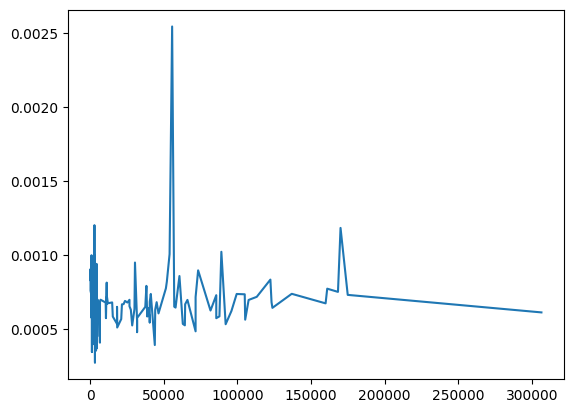

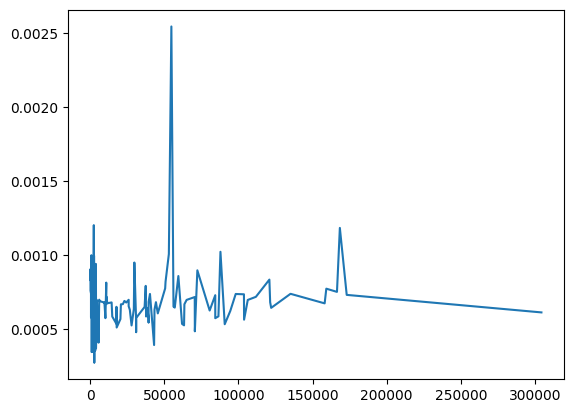

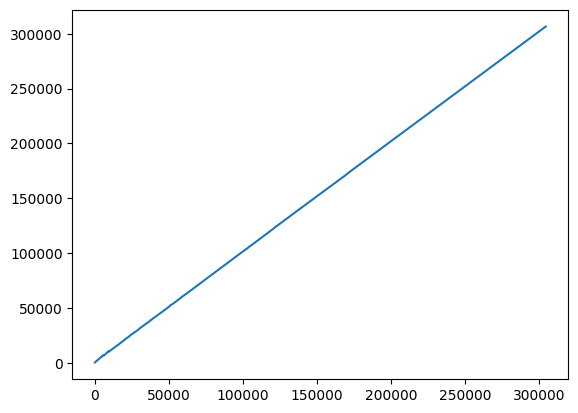

In [46]:
# print(concatenated_df.head)
flopss=np.array(concatenated_df['Flops'])
num_params=np.array(concatenated_df['NumParams'])
gpu_time = np.array(concatenated_df['gpu_time_single'])
# print(flopss)
# print(gpu_time)

srting_idx2=np.argsort(num_params)
srting_idx=np.argsort(flopss)

# print(flopss[srting_idx])
# print(gpu_time[srting_idx])


plt.plot(flopss[srting_idx], gpu_time[srting_idx])
plt.show()

plt.plot(num_params[srting_idx2], gpu_time[srting_idx2])
plt.show()

plt.plot(num_params[srting_idx2], flopss[srting_idx2])
plt.show()

In [47]:
euc_results=concatenated_df[concatenated_df['Distance'] == 'euc'].reset_index()
print(euc_results.shape)
print(euc_results['AUC'].max())
idx=euc_results['AUC'].idxmax()
print(idx)
print(euc_results.iloc[idx]['AUC'])
print(euc_results['Filename'].iloc[idx])
euc_model_path= str(directory+'/'+euc_results['Filename'].iloc[idx]+'.joblib').replace("eval", "model")
print(euc_model_path)
print(euc_results.iloc[idx])
#_GRxYl

(150, 14)
0.9906705433606968
129
0.9906705433606968
2024-12-28_07-19-24-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_GRxYl-withoutInit
/data/dust/user/boukela/code/distance-NAS-EUC/nni/models/EUC/2024-12-28_07-19-24-model-distance-based-euc-epochs-100-Experiment-l3raxpq1_GRxYl-withoutInit.joblib
index                                                                                                       129
Unnamed: 0                                                                                                    0
Distance                                                                                                    euc
Neurons                                                                                                       0
Epochs                                                                                                      100
Accuracy                                                                                               0.995216
AUC                  

## A smaller model can be obtained with almost same performance

In [48]:
filtered_results = euc_results[(euc_results['TPR'] > 0.98) & (euc_results['FPR'] < 0.009)]
sorted_results = filtered_results.sort_values(by='NumParams', ascending=True)
display(sorted_results)
result_list = sorted_results.to_dict(orient='records')

print(result_list)

,index,Unnamed: 0,Distance,Neurons,Epochs,Accuracy,AUC,TPR,FPR,Flops,NumParams,cpu_time_single,gpu_time_single,Filename
94,94,0,euc,0,100,0.995043,0.990584,0.986111,0.004943,11367,10847,0.002391,0.000717,2024-12-28_09-54-59-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_NqA9f-withoutInit
83,83,0,euc,0,100,0.993750,0.989937,0.986111,0.006238,22685,22003,0.003152,0.000666,2024-12-28_21-37-28-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_xKcWK-withoutInit
57,57,0,euc,0,100,0.991488,0.988804,0.986111,0.008504,37431,36671,0.002432,0.000648,2024-12-28_04-15-36-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_GaM27-withoutInit
73,73,0,euc,0,100,0.991703,0.988911,0.986111,0.008288,58001,57009,0.002553,0.000643,2024-12-28_04-03-30-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_Pe62f-withoutInit
76,76,0,euc,0,100,0.991595,0.988858,0.986111,0.008396,87811,86471,0.002308,0.000584,2024-12-28_08-15-07-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_jIo7f-withoutInit
45,45,0,euc,0,100,0.992565,0.989343,0.986111,0.007425,95966,94456,0.003090,0.000620,2024-12-28_04-17-26-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_jOwby-withoutInit
129,129,0,euc,0,100,0.995216,0.990671,0.986111,0.004770,105311,103771,0.003121,0.000561,2024-12-28_07-19-24-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_GRxYl-withoutInit
120,120,0,euc,0,100,0.991078,0.988598,0.986111,0.008914,159941,158121,0.003347,0.000672,2024-12-28_05-00-55-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_oQ9Ug-withoutInit
148,148,0,euc,0,100,0.992263,0.989192,0.986111,0.007727,174976,173006,0.003661,0.000729,2024-12-28_05-15-23-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_UXilS-withoutInit
13,13,0,euc,0,100,0.992199,0.989160,0.986111,0.007792,306576,304366,0.004841,0.000610,2024-12-28_03-49-47-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_gLiCU-withoutInit


[{'index': 94, 'Unnamed: 0': 0, 'Distance': 'euc', 'Neurons': 0, 'Epochs': 100, 'Accuracy': 0.9950434239165572, 'AUC': 0.990584208077625, 'TPR': 0.9861111111111112, 'FPR': 0.004942694955861, 'Flops': 11367, 'NumParams': 10847, 'cpu_time_single': 0.0023909145966172, 'gpu_time_single': 0.0007174720168113, 'Filename': '2024-12-28_09-54-59-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_NqA9f-withoutInit'}, {'index': 83, 'Unnamed: 0': 0, 'Distance': 'euc', 'Neurons': 0, 'Epochs': 100, 'Accuracy': 0.9937504040687024, 'AUC': 0.9899366934545863, 'TPR': 0.9861111111111112, 'FPR': 0.0062377242019382, 'Flops': 22685, 'NumParams': 22003, 'cpu_time_single': 0.0031517799943685, 'gpu_time_single': 0.0006663039922714, 'Filename': '2024-12-28_21-37-28-eval-distance-based-euc-epochs-100-Experiment-l3raxpq1_xKcWK-withoutInit'}, {'index': 57, 'Unnamed: 0': 0, 'Distance': 'euc', 'Neurons': 0, 'Epochs': 100, 'Accuracy': 0.9914876193349568, 'AUC': 0.988803542864269, 'TPR': 0.9861111111111112, 'FPR': 